In [ ]:
"""
=============================================================================
Sign Language Recognition - Data Exploration
=============================================================================
File: notebooks/01_explore_data.ipynb
Description: Explore the WLASL-100 dataset structure, count classes,
             visualize sample images, and understand the data distribution.

=============================================================================
"""


In [2]:
import os
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

# Path to dataset
DATA_DIR = Path("../data/preprocessing")
TRAIN_DIR = DATA_DIR / "train" / "frames"

print("Exploring WLASL-100 Dataset")
print("=" * 50)

Exploring WLASL-100 Dataset


In [3]:
# Räkna antal klasser (ord) och bilder per klass
classes = [d for d in TRAIN_DIR.iterdir() if d.is_dir()]
print(f"Antal klasser (teckenspråksord): {len(classes)}")
print(f"\nFörsta 10 klasserna:")
for c in sorted(classes)[:10]:
    print(f"  - {c.name}")

Antal klasser (teckenspråksord): 100

Första 10 klasserna:
  - accident
  - africa
  - all
  - apple
  - basketball
  - bed
  - before
  - bird
  - birthday
  - black


In [4]:
# Räkna antal bilder per klass
class_counts = {}
for class_dir in classes:
    # Räkna alla jpg-filer i alla undermappar
    num_images = len(list(class_dir.rglob("*.jpg")))
    class_counts[class_dir.name] = num_images

# Visa statistik
total_images = sum(class_counts.values())
print(f"Totalt antal bilder: {total_images}")
print(f"Genomsnitt per klass: {total_images // len(classes)}")
print(f"Min bilder i en klass: {min(class_counts.values())}")
print(f"Max bilder i en klass: {max(class_counts.values())}")

Totalt antal bilder: 23040
Genomsnitt per klass: 230
Min bilder i en klass: 192
Max bilder i en klass: 480


Klass: accident
Bild: accident_10.jpg


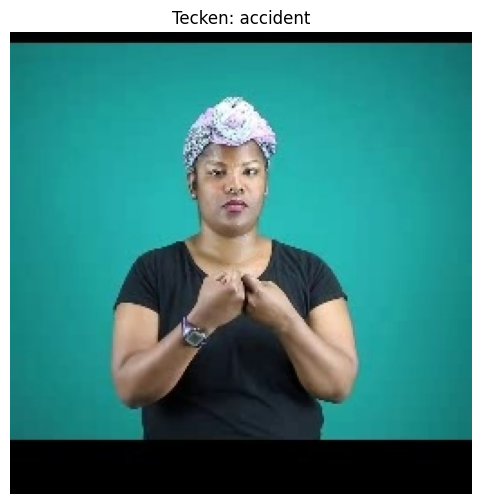

Bildstorlek: (256, 256)


In [5]:
# Visa en exempelbild
from PIL import Image

# Välj första klassen och första bilden
first_class = sorted(classes)[0]
first_image = list(first_class.rglob("*.jpg"))[0]

print(f"Klass: {first_class.name}")
print(f"Bild: {first_image.name}")

# Visa bilden
img = Image.open(first_image)
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Tecken: {first_class.name}")
plt.axis('off')
plt.show()

print(f"Bildstorlek: {img.size}")

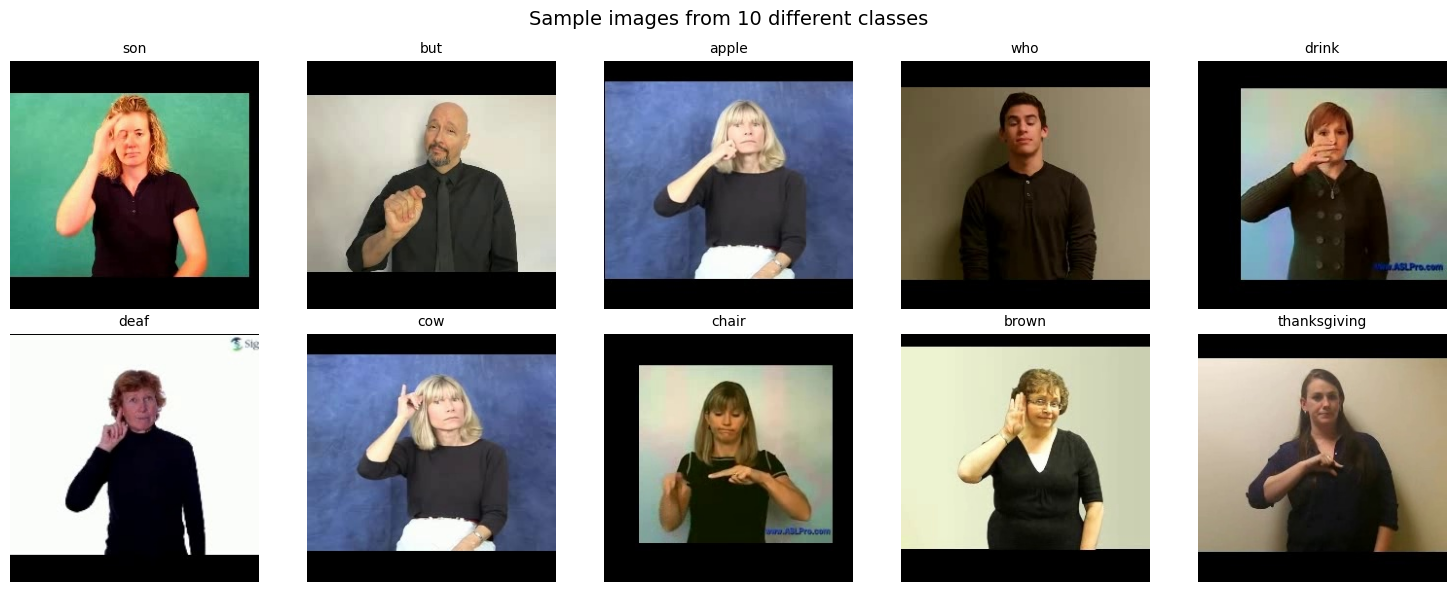

In [6]:
# Visa bilder från flera olika klasser
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

# Välj 10 slumpmässiga klasser
import random
random.seed(42)
sample_classes = random.sample(sorted(classes), 10)

for ax, class_dir in zip(axes, sample_classes):
    # Hämta första bilden från klassen
    image_path = list(class_dir.rglob("*.jpg"))[0]
    img = Image.open(image_path)
    
    ax.imshow(img)
    ax.set_title(class_dir.name, fontsize=10)
    ax.axis('off')

plt.suptitle("Sample images from 10 different classes", fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
# Analysera genomsnittlig färg i bildernas hörn (bakgrund)
import numpy as np

def get_corner_color(img_path):
    """Hämta färg från övre vänstra hörnet (bakgrund)"""
    img = Image.open(img_path)
    img_array = np.array(img)
    # Ta genomsnitt av 20x20 pixlar i hörnet
    corner = img_array[:20, :20, :]
    return corner.mean(axis=(0,1))

# Kolla bakgrundsfärg för 100 slumpmässiga bilder
sample_images = []
for class_dir in random.sample(sorted(classes), 20):
    images = list(class_dir.rglob("*.jpg"))[:5]
    sample_images.extend(images)

colors = [get_corner_color(img) for img in sample_images]
colors = np.array(colors)

print("Bakgrundsfärgsanalys (RGB-värden):")
print(f"  Genomsnitt: R={colors[:,0].mean():.0f}, G={colors[:,1].mean():.0f}, B={colors[:,2].mean():.0f}")
print(f"  Min: R={colors[:,0].min():.0f}, G={colors[:,1].min():.0f}, B={colors[:,2].min():.0f}")
print(f"  Max: R={colors[:,0].max():.0f}, G={colors[:,1].max():.0f}, B={colors[:,2].max():.0f}")

Bakgrundsfärgsanalys (RGB-värden):
  Genomsnitt: R=30, G=31, B=29
  Min: R=0, G=0, B=0
  Max: R=188, G=190, B=188


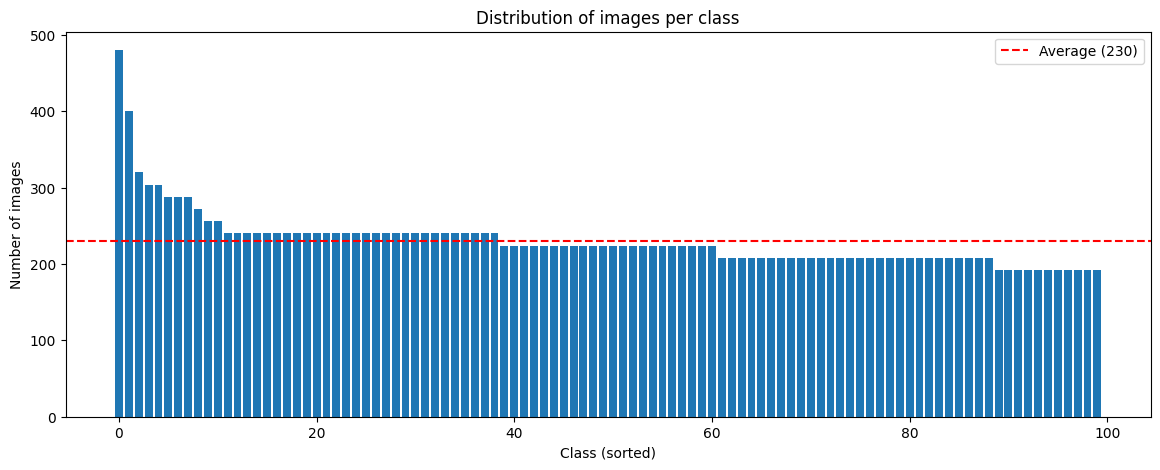

In [8]:
# Visualisera fördelning av bilder per klass
plt.figure(figsize=(14, 5))
sorted_counts = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))
plt.bar(range(len(sorted_counts)), sorted_counts.values())
plt.xlabel('Class (sorted)')
plt.ylabel('Number of images')
plt.title('Distribution of images per class')
plt.axhline(y=230, color='r', linestyle='--', label='Average (230)')
plt.legend()
plt.show()

In [9]:
# Sammanfattning av datasetanalysen
print("=" * 60)
print("SAMMANFATTNING: WLASL-100 Dataset")
print("=" * 60)
print(f"""
Antal klasser:          {len(classes)}
Totalt antal bilder:    {total_images}
Bilder per klass:       {min(class_counts.values())} - {max(class_counts.values())} (snitt: {total_images // len(classes)})
Bildstorlek:            256 x 256 pixlar
Format:                 JPG
Uppdelning:             train / test / val

Observationer:
- Varierande bakgrundsfärger (svart, grå, grön, blå)
- Olika personer med olika utseenden
- Lite obalanserad data (vissa klasser har mer bilder)
- Vattenstämplar på vissa bilder

Nästa steg:
- Extrahera hand/pose-features med MediaPipe
- Träna klassificeringsmodell
- Deploya till AWS (SageMaker, EC2, Fargate)
""")

SAMMANFATTNING: WLASL-100 Dataset

Antal klasser:          100
Totalt antal bilder:    23040
Bilder per klass:       192 - 480 (snitt: 230)
Bildstorlek:            256 x 256 pixlar
Format:                 JPG
Uppdelning:             train / test / val

Observationer:
- Varierande bakgrundsfärger (svart, grå, grön, blå)
- Olika personer med olika utseenden
- Lite obalanserad data (vissa klasser har mer bilder)
- Vattenstämplar på vissa bilder

Nästa steg:
- Extrahera hand/pose-features med MediaPipe
- Träna klassificeringsmodell
- Deploya till AWS (SageMaker, EC2, Fargate)

